In [25]:
!pip install -q ultralytics

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


# **DEPENDENCIES**

In [2]:
import os
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from glob import glob
from xml.dom import minidom
import random
import easyocr
from ultralytics import YOLO
import yaml
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import torch
import pytesseract
from PIL import Image

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# `convert_xml2yolo` Function

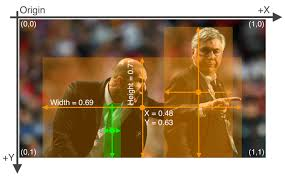

## Overview
The `convert_xml2yolo` function is designed to convert object detection annotations from XML format (commonly used in datasets like Pascal VOC) to YOLO format. This conversion is essential for training object detection models using the YOLO framework, which requires annotations in a specific format.

## Function Signature
```python
def convert_xml2yolo(lut, input_path, output_path):
```

### Parameters
- **`lut`**: A dictionary that maps class names (strings) to numeric labels (integers). This is used to assign YOLO-compatible class IDs to the objects in the annotations.
- **`input_path`**: The directory containing the XML annotation files.
- **`output_path`**: The directory where the converted YOLO annotation files will be saved.

## Workflow
1. **Check Output Directory**:
   - If the specified `output_path` does not exist, it is created using `os.mkdir`.

2. **Iterate Over XML Files**:
   - The function uses the `glob` module to find all XML files in the `input_path` directory.

3. **Parse XML File**:
   - Each XML file is parsed using the `minidom` module to extract annotation details.

4. **Extract Image Dimensions**:
   - The width and height of the image are retrieved from the `<size>` tag in the XML file.

5. **Process Each Object**:
   - For each `<object>` tag in the XML file:
     - The class name is mapped to a numeric label using the `lut` dictionary.
     - The bounding box coordinates (`xmin`, `ymin`, `xmax`, `ymax`) are extracted and converted to YOLO format using the `convert_coordinates` helper function.

6. **Write YOLO Annotation File**:
   - The converted annotations are written to a `.txt` file in the `output_path` directory.

7. **Completion Message**:
   - A message is printed to indicate that the conversion process is finished.

## Helper Function: `convert_coordinates`
The `convert_coordinates` function is used to transform bounding box coordinates from absolute pixel values to normalized YOLO format.

### Formula
Given:
- Image dimensions: `(width, height)`
- Bounding box: `(xmin, xmax, ymin, ymax)`

The YOLO format is calculated as:
- `x_center = (xmin + xmax) / 2 / width`
- `y_center = (ymin + ymax) / 2 / height`
- `box_width = (xmax - xmin) / width`
- `box_height = (ymax - ymin) / height`

### Code
```python
def convert_coordinates(size, box):
    dw = 1.0 / size[0]
    dh = 1.0 / size[1]
    x = (box[0] + box[1]) / 2.0
    y = (box[2] + box[3]) / 2.0
    w = box[1] - box[0]
    h = box[3] - box[2]
    x = x * dw
    w = w * dw
    y = y * dh
    h = h * dh
    return (x, y, w, h)
```

## Example Usage
```python
lut = {
    "car": 0,
    "person": 1,
    "bicycle": 2
}

convert_xml2yolo(
    lut,
    input_path="/path/to/xml/annotations",
    output_path="/path/to/yolo/annotations"
)
```

## Notes
- If a class name in the XML file is not found in the `lut` dictionary, it is assigned a default label of `0`.
- The function assumes that the XML files follow the Pascal VOC format.

## Output Format
Each line in the YOLO annotation file corresponds to an object and follows the format:
```
<class_id> <x_center> <y_center> <width> <height>
```
All values are normalized to the range `[0, 1]`.

## Conclusion
The `convert_xml2yolo` function simplifies the process of preparing annotation data for YOLO-based object detection models. By automating the conversion from XML to YOLO format, it ensures compatibility and reduces manual effort.
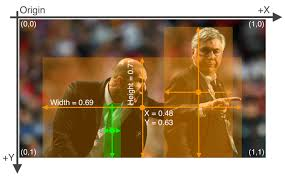

In [26]:
# -*- coding: utf-8 -*-

lut={}
lut["accessory"] =0
lut["top"]       =1
lut["bottom"]    =2
lut["bag"]       =3
lut["shoes"]     =4



def convert_coordinates(size, box):
    dw = 1.0/size[0]
    dh = 1.0/size[1]
    x = (box[0]+box[1])/2.0
    y = (box[2]+box[3])/2.0
    w = box[1]-box[0]
    h = box[3]-box[2]
    x = x*dw
    w = w*dw
    y = y*dh
    h = h*dh
    return (x,y,w,h)


def convert_xml2yolo( lut,input_path, output_path ):

    if not os.path.exists(output_path):
         os.mkdir(output_path) 
        
    for fname in glob(f"{input_path}/*.xml"):
        
        xmldoc = minidom.parse(fname)
        annot_fname = fname.split("/")[-1][:-4]
        fname_out = f"{output_path}/{annot_fname}.txt"
        
        with open(fname_out, "w") as f:
            
            itemlist = xmldoc.getElementsByTagName('object')
            size = xmldoc.getElementsByTagName('size')[0]
            width = int((size.getElementsByTagName('width')[0]).firstChild.data)
            height = int((size.getElementsByTagName('height')[0]).firstChild.data)

            for item in itemlist:
                # get class label
                classid =  (item.getElementsByTagName('name')[0]).firstChild.data
                if classid in lut:
                    label_str = str(lut[classid])
                else:
                    label_str = "0"
                    #print ("warning: label '%s' not in look-up table" % classid)

                # get bbox coordinates
                xmin = ((item.getElementsByTagName('bndbox')[0]).getElementsByTagName('xmin')[0]).firstChild.data
                ymin = ((item.getElementsByTagName('bndbox')[0]).getElementsByTagName('ymin')[0]).firstChild.data
                xmax = ((item.getElementsByTagName('bndbox')[0]).getElementsByTagName('xmax')[0]).firstChild.data
                ymax = ((item.getElementsByTagName('bndbox')[0]).getElementsByTagName('ymax')[0]).firstChild.data
                b = (float(xmin), float(xmax), float(ymin), float(ymax))
                bb = convert_coordinates((width,height), b)
                #print(bb)

                f.write(label_str + " " + " ".join([("%.6f" % a) for a in bb]) + '\n')

        #print ("wrote %s" % fname_out)
    print("Converting is finished!")

convert_xml2yolo( lut, input_path = "/kaggle/input/car-plate-detection/annotations", output_path = "/kaggle/working/annotations")

Converting is finished!


# **VAL & TRAIN SPLIT PATHS**

In [27]:
def create_directories_if_not_exist(directories: list):
    # Assert: Is the parameter a list?
    assert isinstance(directories, list), "The parameter must be a list (array)."
    
    # Assert: Is every element in the list a string?
    for dir_path in directories:
        assert isinstance(dir_path, str), f"The element '{dir_path}' in the list is not a string."

    # Create directories
    for dir_path in directories:
        if not os.path.exists(dir_path):
            os.mkdir(dir_path)
            print(f"Created: {dir_path}")
        else:
            print(f"Already exists: {dir_path}")

In [5]:
directories = [
    "/kaggle/working/car_plate_dataset",
    "/kaggle/working/car_plate_dataset/images",
    "/kaggle/working/car_plate_dataset/labels",
    "/kaggle/working/car_plate_dataset/images/train",
    "/kaggle/working/car_plate_dataset/images/val",
    "/kaggle/working/car_plate_dataset/labels/train",
    "/kaggle/working/car_plate_dataset/labels/val"
]

create_directories_if_not_exist(directories)

Created: /kaggle/working/car_plate_dataset
Created: /kaggle/working/car_plate_dataset/images
Created: /kaggle/working/car_plate_dataset/labels
Created: /kaggle/working/car_plate_dataset/images/train
Created: /kaggle/working/car_plate_dataset/images/val
Created: /kaggle/working/car_plate_dataset/labels/train
Created: /kaggle/working/car_plate_dataset/labels/val


# `split_images_and_labels` Function

## Overview
The `split_images_and_labels` function splits a dataset of images and labels into training and validation sets, useful for machine learning tasks like object detection.

## Parameters
- `val_size` (float): Proportion of the dataset for validation (default: 0.1).
- `input_dir` (str): Directory containing `images/` and `annotations/` subfolders.
- `output_dir` (str): Directory where the split dataset will be saved.

## Workflow
1. **Splitting:** Images are divided into `train` and `val` sets based on `val_size`.
2. **Copying:** Files are copied to `output_dir` under `images/train`, `images/val`, `labels/train`, and `labels/val`.
3. **Completion:** Prints a message when done.

## Example Usage
```python
split_images_and_labels(
    val_size=0.2,
    input_dir="/path/to/input",
    output_dir="/path/to/output"
)
```

## Notes
- Assumes matching filenames for images and labels (e.g., `image1.jpg` and `image1.txt`).
- Creates `output_dir` if it doesn’t exist.

## Output Example
For `val_size=0.5`:
```plaintext
output_dir/
    images/
        train/
            car1.jpg
        val/
            car2.jpg
    labels/
        train/
            car1.txt
        val/
            car2.txt
```


In [6]:
def split_images_and_labels(val_size = 0.1, input_dir = "/kaggle/input/car-plate-detection",
                           output_dir = "/kaggle/working/car_plate_dataset"):
    
        img_path = os.listdir(f"{input_dir}/images")
        label_path = os.listdir(f"{input_dir}/annotations")
        imgs_length = len(img_path)
        for i,img in enumerate(img_path):
            spname = "train" if i < int(imgs_length*float(1 - val_size)) else "val"
            
            #print(spname)
            
            os.system(f"cp {input_dir}/images/{img} {output_dir}/images/{spname}/{img}")
            #print(f"the image {input_dir}/images/{img} image copied to {output_dir}/images/{spname}/{img}")
            
            os.system(f"cp /kaggle/working/annotations/{img.split('.')[0]}.txt {output_dir}/labels/{spname}/{img.split('.')[0]}.txt")
            #print(f"the label /kaggle/working/annotations/{img.split('.')[0]}.txt image copied to {output_dir}/labels/{spname}/{img.split('.')[0]}.txt")  
    
        print("Splitting is finished!")
    
split_images_and_labels()

Splitting is finished!


## **YAML PARAMETERS**

In [7]:
# Data to be written to the YAML file
data = {
    'train': '/kaggle/working/car_plate_dataset/images/train',
    'val': '/kaggle/working/car_plate_dataset/images/val',
    'names': {
        0: "number_plate"
    } # List formatında olmalı!
}

# Writing the data to a YAML file
with open('data.yaml', 'w') as file:
    yaml.dump(data, file, default_flow_style=False)

print("Data has been written to 'data.yaml'")

Data has been written to 'data.yaml'


# Visualization

## Overview
This script visualizes a grid of images with bounding boxes drawn from YOLO annotations. It is useful for verifying the correctness of annotations and inspecting the dataset.

## Workflow
1. **File Collection:**
   - Collects image files from the specified directory (`image_dir`) with supported extensions (`*.jpg`, `*.jpeg`, `*.png`).
   - Selects the first 9 images for visualization.

2. **Grid Creation:**
   - Creates a 3x3 grid using Matplotlib to display the images.

3. **Bounding Box Drawing:**
   - For each image, the corresponding YOLO annotation file is read.
   - Bounding boxes are converted from YOLO format to pixel coordinates and drawn on the image.

4. **Display:**
   - Displays the grid of images with bounding boxes using Matplotlib.

## Key Variables
- `image_dir`: Path to the directory containing the images.
- `label_dir`: Path to the directory containing the YOLO annotation files.
- `image_extensions`: List of supported image file extensions.

## Example Usage
```python
# File paths
image_dir = "/path/to/images"
label_dir = "/path/to/labels"

# Supported extensions
image_extensions = ["*.jpg", "*.jpeg", "*.png"]

# Visualization script
# (Refer to the script in `main.py` for full implementation)
```

## Notes
- The script assumes that the filenames of the images and their corresponding labels match (e.g., `image1.jpg` and `image1.txt`).
- Bounding boxes are drawn in red for better visibility.
- Ensure that the `image_dir` and `label_dir` paths are correctly set before running the script.

## Output Example
The script generates a 3x3 grid of images with bounding boxes drawn, as shown below:

```
+---------+---------+---------+
| Image 1 | Image 2 | Image 3 |
+---------+---------+---------+
| Image 4 | Image 5 | Image 6 |
+---------+---------+---------+
| Image 7 | Image 8 | Image 9 |
+---------+---------+---------+
```

Bounding boxes are overlaid on the images in red.


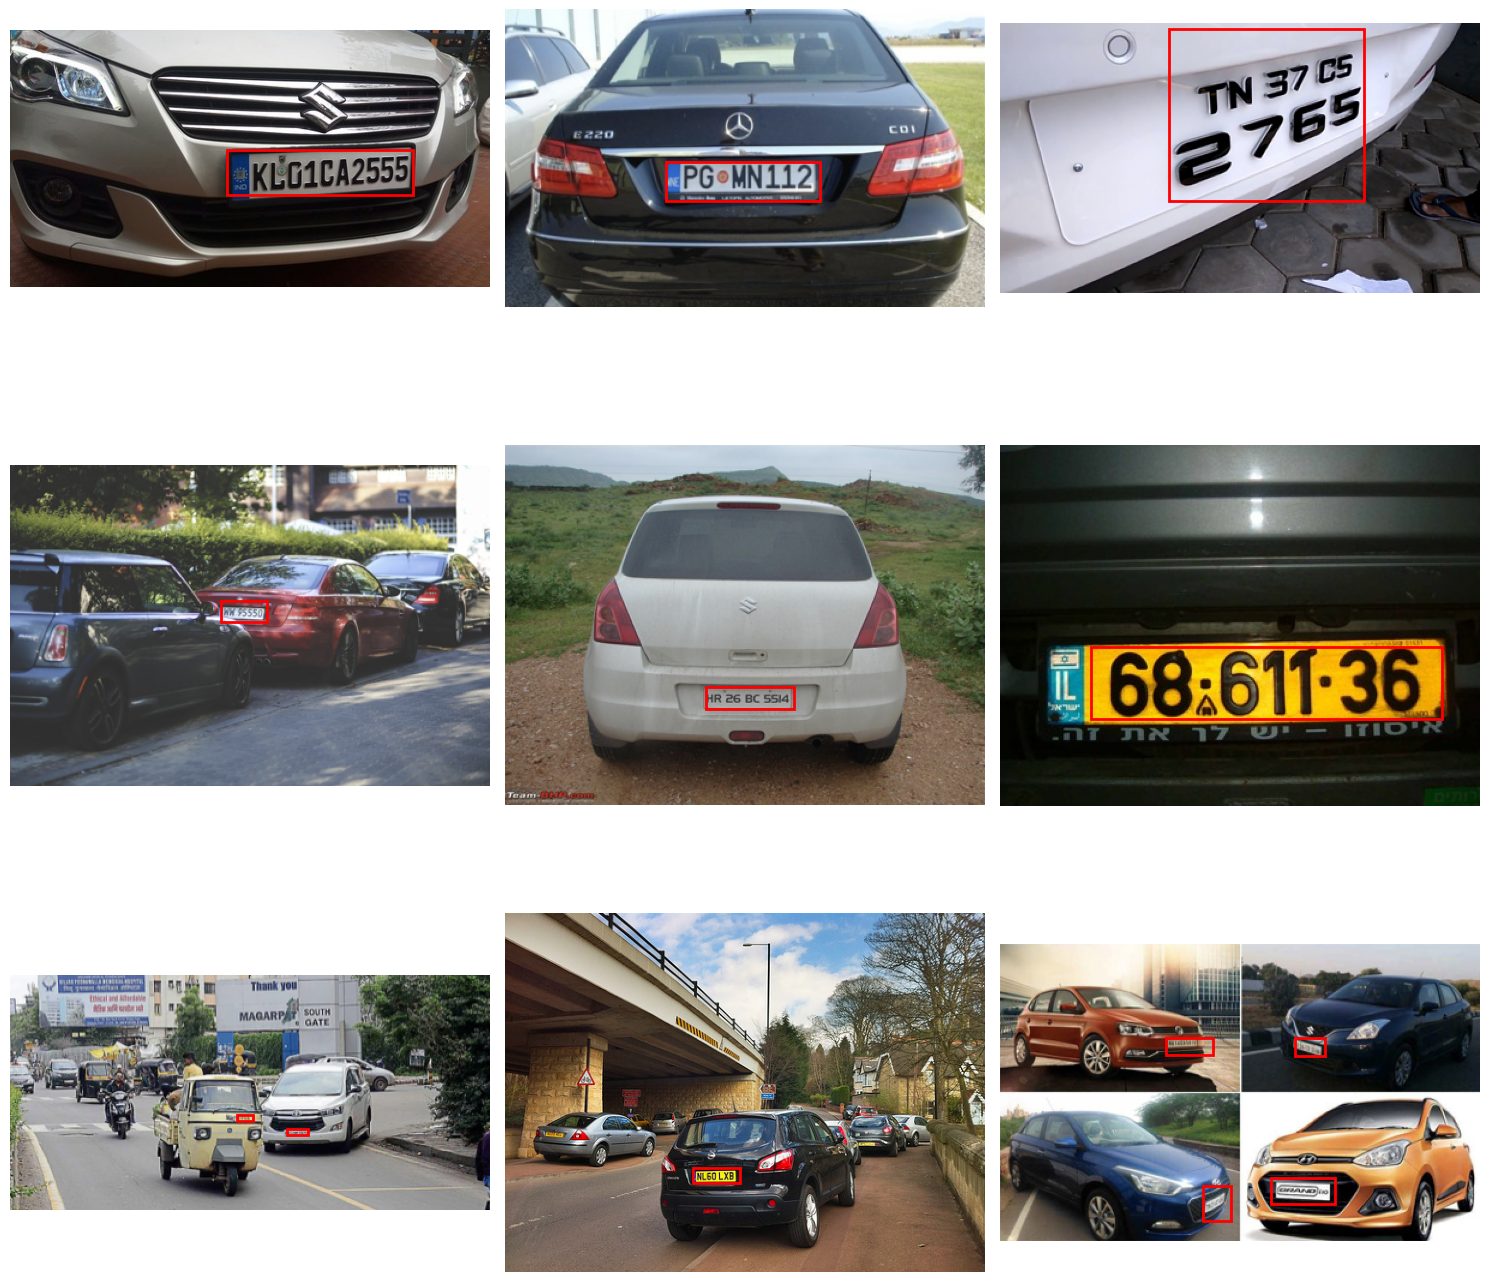

In [8]:
# File paths
image_dir = "/kaggle/working/car_plate_dataset/images/train"
label_dir = "/kaggle/working/car_plate_dataset/labels/train"

# Supported extensions
image_extensions = ["*.jpg", "*.jpeg", "*.png"]

# Collect all image files
image_paths = []
for ext in image_extensions:
    image_paths.extend(glob(os.path.join(image_dir, ext)))

# Use the first 9 images
image_paths = sorted(image_paths)[:9]

# Draw a 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for idx, image_path in enumerate(image_paths):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    
    # Find the corresponding label file (change extension to .txt)
    base_name = os.path.splitext(os.path.basename(image_path))[0]
    label_path = os.path.join(label_dir, base_name + ".txt")
    
    # Draw with Matplotlib
    ax = axes[idx]
    ax.imshow(img)
    ax.axis("off")
    
    # Draw boxes if labels exist
    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            lines = f.readlines()
        
        for line in lines:
            class_id, x_center, y_center, box_width, box_height = map(float, line.strip().split())
            
            # Convert from YOLO format to pixels
            x1 = int((x_center - box_width / 2) * w)
            y1 = int((y_center - box_height / 2) * h)
            x2 = int((x_center + box_width / 2) * w)
            y2 = int((y_center + box_height / 2) * h)
            
            # Draw rectangle
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                     linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)

plt.tight_layout()
plt.show()

# YOLO Training

## Overview of YOLO
YOLO (You Only Look Once) is a state-of-the-art object detection algorithm that performs detection in a single pass through the network. Unlike traditional methods that use region proposals and multiple stages, YOLO treats object detection as a regression problem, predicting bounding boxes and class probabilities directly from the input image.

### Key Features of YOLO
1. **Speed:** YOLO is extremely fast because it processes the entire image in a single forward pass.
2. **Accuracy:** It achieves high accuracy by learning global image context and spatial relationships.
3. **Unified Architecture:** YOLO uses a single convolutional neural network (CNN) to predict bounding boxes and class probabilities simultaneously.

## Explanation of IoU and mAP Metrics

### Intersection over Union (IoU)
IoU measures the overlap between two bounding boxes, typically the predicted and ground truth boxes. It is defined as:
$$ IoU = \frac{Area\ of\ Overlap}{Area\ of\ Union} $$

- **Area of Overlap:** The area where the predicted and ground truth boxes intersect.
- **Area of Union:** The total area covered by both boxes.

IoU ranges from 0 to 1, where 1 indicates perfect overlap. It is used to determine whether a predicted bounding box is a true positive or a false positive.

### Mean Average Precision (mAP)
mAP evaluates the performance of object detection models by calculating the average precision (AP) for each class and then taking the mean.

#### Average Precision (AP)
AP is the area under the Precision-Recall curve for a specific class. It is calculated as:
$$ AP = \int_0^1 P(R) dR $$

- **P(R):** Precision as a function of Recall.

#### Mean Average Precision
The mAP is then calculated as:
$$ mAP = \frac{1}{N} \sum_{i=1}^{N} AP_i $$

- **N:** Total number of classes.
- **AP_i:** Average Precision for class $i$.

## Explanation of the Training Code

### GPU Configuration
```python
gpu_count = torch.cuda.device_count()
device = list(range(gpu_count)) if gpu_count > 1 else 0
```
- **`torch.cuda.device_count()`:** Checks the number of available GPUs.
- **`device`:** Sets the device to use multiple GPUs if available, otherwise defaults to a single GPU.

### Model Initialization
```python
model = YOLO("yolo11n.pt")
```
- **`YOLO`:** Initializes the YOLO model with the specified weights file (`yolo11n.pt`).

### Training Configuration
```python
results = model.train(
    data="/kaggle/working/data.yaml",   # Dataset configuration
    epochs=200,                         # 200 epochs
    imgsz=640,                          # Suitable for smaller images
    batch=32,                           # Adjustable based on GPU RAM
    workers=2,                          # Ideal starting value for Tesla T4
    device=device,                      # GPU setting
    augment=True,                       # Default YOLO augmentations are automatically enabled
    patience=20,                        # Stops early if no improvement for 20 epochs
    val=True,                           # Validation is performed at the end of each epoch
)
```
#### Key Parameters
- **`data`:** Path to the dataset configuration file (`data.yaml`).
- **`epochs`:** Number of training epochs (200 in this case).
- **`imgsz`:** Image size for training (640x640 pixels).
- **`batch`:** Batch size, adjustable based on GPU memory.
- **`workers`:** Number of data loader workers (2 is ideal for Tesla T4 GPUs).
- **`device`:** Specifies the GPU(s) to use.
- **`augment`:** Enables default YOLO augmentations for data augmentation.
- **`patience`:** Early stopping if no improvement for 20 epochs.
- **`val`:** Enables validation at the end of each epoch.

## Notes
- Ensure that the dataset is correctly formatted and the `data.yaml` file is properly configured.
- Adjust the `batch` size and `workers` based on the available GPU resources.
- Use a pre-trained weights file (e.g., `yolo11n.pt`) to speed up training and improve accuracy.

## Output
The training process outputs:
1. **Model Weights:** Saved at regular intervals and at the end of training.
2. **Metrics:** Training and validation loss, mAP, and other performance metrics.
3. **Logs:** Detailed logs for each epoch, including loss and mAP values.

This documentation provides a comprehensive explanation of the YOLO training process, including the metrics and code used. Let me know if you need further clarifications or additional details!


In [17]:
# Check the number of GPUs
gpu_count = torch.cuda.device_count()
device = list(range(gpu_count)) if gpu_count > 1 else 0

model = YOLO("yolo11n.pt")

results = model.train(
    data="/kaggle/working/data.yaml",   # Dataset configuration
    epochs=200,                         # 200 epochs
    imgsz=640,                          # Suitable for smaller images
    batch=32,                            # Adjustable based on GPU RAM
    workers=2,                          # Ideal starting value for Tesla T4
    device=device,                      # GPU setting

    # ✅ Default Regularization & Optimization (YOLO uses its own defaults)
    # If you don't define these parameters, defaults will be used.

    # ✅ Default Augmentations
    augment=True,                       # Default YOLO augmentations are automatically enabled

    # ✅ Early Stopping and Validation
    patience=20,                        # Stops early if no improvement for 10 epochs
    val=True,                           # Validation is performed at the end of each epoch
)

Ultralytics 8.3.134 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspective=0.0, plots=True, pose=12.0, pretrained=True,

train: Scanning /kaggle/working/car_plate_dataset/labels/train.cache... 389 images, 0 backgrounds, 0 corrupt: 100%|██████████| 389/389 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 593.2±110.6 MB/s, size: 400.5 KB)


val: Scanning /kaggle/working/car_plate_dataset/labels/val.cache... 44 images, 0 backgrounds, 0 corrupt: 100%|██████████| 44/44 [00:00<?, ?it/s]


...


73 epochs completed in 0.105 hours.
Optimizer stripped from runs/detect/train8/weights/last.pt, 5.5MB
Optimizer stripped from runs/detect/train8/weights/best.pt, 5.5MB

Validating runs/detect/train8/weights/best.pt...
Ultralytics 8.3.134 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  1.95it/s]


                   all         44         45       0.85      0.889      0.882      0.605


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 0.2ms preprocess, 6.8ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to runs/detect/train8


# License Plate Detection and OCR Documentation

## Overview
This script performs license plate detection and Optical Character Recognition (OCR) on a set of images. It uses the YOLO object detection model to locate license plates and Tesseract OCR to extract text from the detected plates. The script is designed for Turkish license plates and includes preprocessing steps to improve OCR accuracy.

## Workflow
1. **Image Loading:**
   - Randomly selects a subset of images from the dataset.
   - Reads and converts images to RGB format for processing.

2. **License Plate Detection:**
   - Uses a YOLO model to detect license plates in the images.
   - Extracts bounding box coordinates for each detected plate.

3. **Preprocessing:**
   - Converts the license plate region to grayscale.
   - Crops the left side of the plate (removing the blue "TR" section).
   - Applies Gaussian blur and thresholding to enhance text clarity.

4. **OCR:**
   - Uses Tesseract OCR to extract text from the preprocessed license plate region.
   - Formats the extracted text to match Turkish license plate standards.

5. **Visualization:**
   - Draws bounding boxes and recognized text on the images.
   - Displays the processed images with Matplotlib.

6. **Output:**
   - Prints the recognized license plate text for each image.

## Key Functions and Code Snippets

### YOLO Model Initialization
```python
model = YOLO("runs/detect/train/weights/best.pt")
```
- Loads the YOLO model with pre-trained weights.
- Used for detecting license plates in images.

### OCR Preprocessing
```python
plate_img = img[y1:y2, x1:x2]
gray = cv2.cvtColor(plate_img, cv2.COLOR_BGR2GRAY)
cut_x = int(w * 0.10)  # Remove 10% from the left
gray = gray[:, cut_x:]
blurred = cv2.GaussianBlur(gray, (5, 5), 1)
_, thresh = cv2.threshold(blurred, 150, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
```
- Extracts the license plate region from the image.
- Converts the region to grayscale and removes the left side.
- Applies Gaussian blur and thresholding to prepare the region for OCR.

### OCR with Tesseract
```python
text = pytesseract.image_to_string(thresh, config=custom_config)
formatted_text = format_turkish_plate(text)
```
- Extracts text from the preprocessed license plate region.
- Formats the text to match Turkish license plate standards.

### Visualization
```python
cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (255, 0, 0), 3)
cv2.putText(img_rgb, formatted_text, (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2, cv2.LINE_AA)
```
- Draws a bounding box around the detected license plate.
- Adds the recognized text above the bounding box.

### Displaying Results
```python
plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()
```
- Displays the processed image with bounding boxes and recognized text.

## Example Usage
```python
# Load images
image_paths = glob("/path/to/images/*.jpg")
random_images = random.sample(image_paths, 10)

# Process each image
for img_path in random_images:
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = model(img_path, conf=0.4, iou=0.4)
    # Further processing as described above
```

## Notes
- Ensure that the YOLO model weights and Tesseract OCR are correctly installed and configured.
- The script is optimized for Turkish license plates but can be adapted for other formats with minor modifications.
- Adjust the confidence (`conf`) and IoU thresholds for YOLO as needed.

## Output Example
For an image with a detected license plate, the script outputs:
- The processed image with bounding boxes and recognized text.
- The recognized license plate text printed to the console:
  ```
  Plate 1: 34ABC123
  ```



image 1/1 /kaggle/input/turkish-license-plate-dataset/images/89.jpg: 640x384 1 number_plate, 9.9ms
Speed: 2.3ms preprocess, 9.9ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 384)


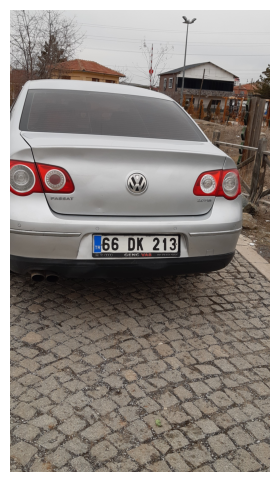


image 1/1 /kaggle/input/turkish-license-plate-dataset/images/67.jpg: 640x384 1 number_plate, 9.2ms
Speed: 2.4ms preprocess, 9.2ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 384)


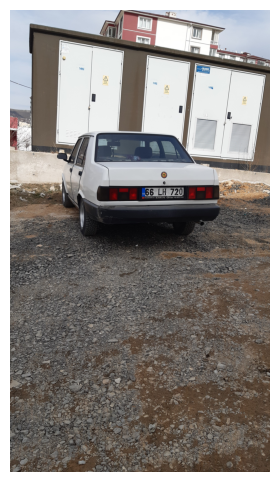


image 1/1 /kaggle/input/turkish-license-plate-dataset/images/546.jpg: 640x640 1 number_plate, 9.6ms
Speed: 3.6ms preprocess, 9.6ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


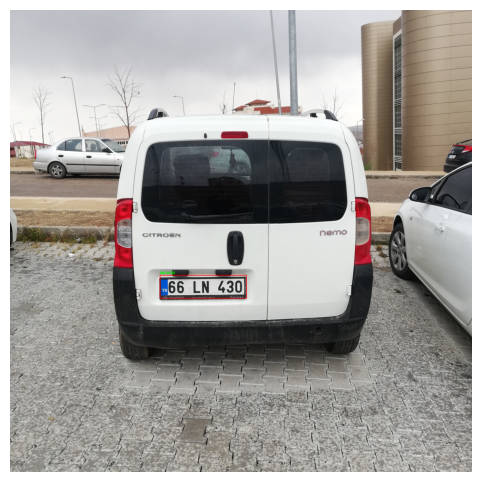

Plate 1: 66LN430

image 1/1 /kaggle/input/turkish-license-plate-dataset/images/1852.jpg: 640x480 1 number_plate, 10.1ms
Speed: 2.1ms preprocess, 10.1ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 480)


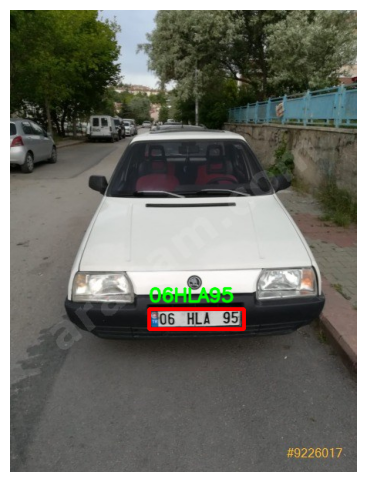

Plate 1: 06HLA95

image 1/1 /kaggle/input/turkish-license-plate-dataset/images/1837.jpg: 640x480 1 number_plate, 9.8ms
Speed: 2.3ms preprocess, 9.8ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 480)


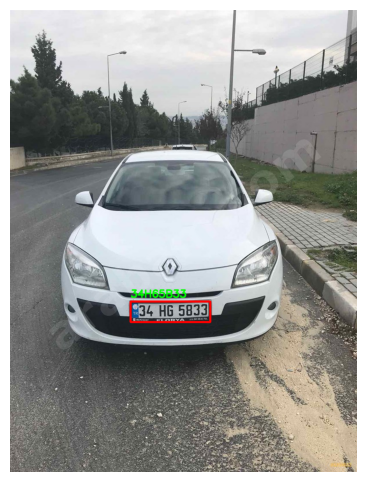

Plate 1: 34H65B33

image 1/1 /kaggle/input/turkish-license-plate-dataset/images/791.jpg: 640x640 2 number_plates, 9.9ms
Speed: 3.6ms preprocess, 9.9ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


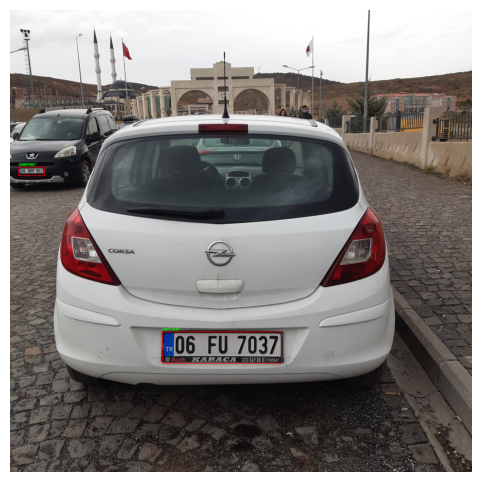

Plate 1: 06FU1037
Plate 2: 06BRP867

image 1/1 /kaggle/input/turkish-license-plate-dataset/images/1176.jpg: 640x480 2 number_plates, 9.5ms
Speed: 2.3ms preprocess, 9.5ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)


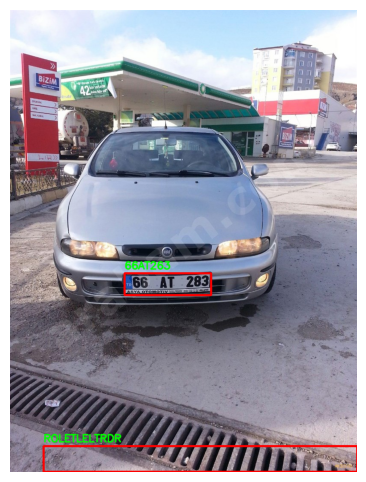

Plate 1: 66AT263
Plate 2: ROLETLELTRDR

image 1/1 /kaggle/input/turkish-license-plate-dataset/images/1030.jpg: 640x512 2 number_plates, 43.2ms
Speed: 2.1ms preprocess, 43.2ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 512)


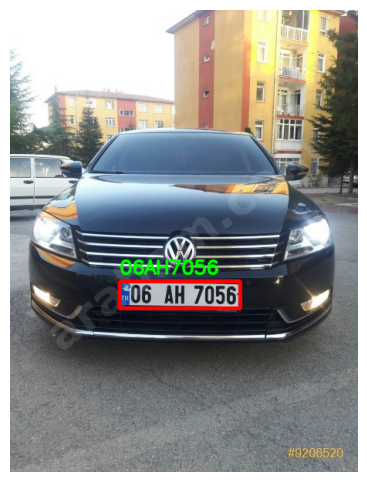

Plate 1: 06AH7056

image 1/1 /kaggle/input/turkish-license-plate-dataset/images/1128.jpg: 480x640 1 number_plate, 9.8ms
Speed: 2.5ms preprocess, 9.8ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)


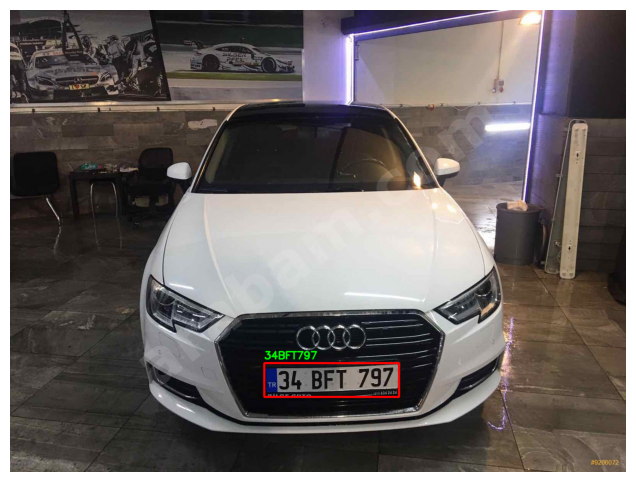

Plate 1: 34BFT797

image 1/1 /kaggle/input/turkish-license-plate-dataset/images/692.jpg: 640x640 3 number_plates, 10.2ms
Speed: 3.7ms preprocess, 10.2ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


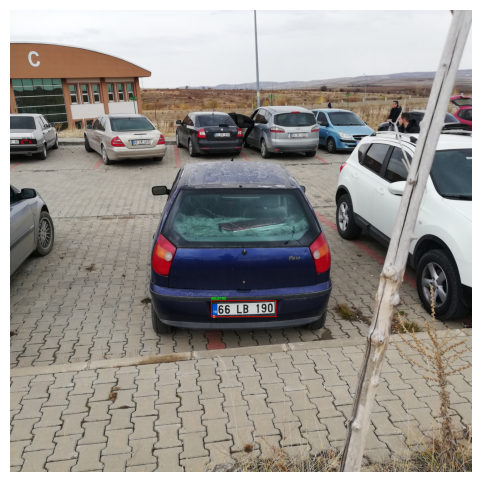

Plate 1: 66LB190


In [24]:
import cv2
import random
import pytesseract
import matplotlib.pyplot as plt
from glob import glob
from ultralytics import YOLO

# Tesseract ayarları
custom_config = r'--oem 3 --psm 7 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'

# YOLO modelini yükle
model = YOLO("runs/detect/train/weights/best.pt")

# Görüntüleri al
image_paths = glob("/kaggle/input/turkish-license-plate-dataset/images/*.png") + \
              glob("/kaggle/input/turkish-license-plate-dataset/images/*.jpg")

num_images = min(10, len(image_paths))
random_images = random.sample(image_paths, num_images)

# Boşluksuz Türk plaka formatlayıcı
def format_turkish_plate(text):
    return text.strip().upper().replace(" ", "").replace("-", "")

# Görüntüler üzerinde işlem yap
for img_path in random_images:
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    results = model(img_path, conf=0.4, iou=0.4)
    detected_text_list = []

    for result in results:
        boxes = result.boxes
        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0].int().tolist()

            # Plaka bölgesini al ve ön işleme uygula
            plate_img = img[y1:y2, x1:x2]
            gray = cv2.cvtColor(plate_img, cv2.COLOR_BGR2GRAY)

            # Sol taraf (mavi TR kısmı) kesiliyor
            h, w = gray.shape
            cut_x = int(w * 0.10)  # %20'sini kes
            gray = gray[:, cut_x:]

            # Orta düzey Gaussian Blur
            blurred = cv2.GaussianBlur(gray, (5, 5), 1)

            # Threshold ile netleştirme
            _, thresh = cv2.threshold(blurred, 150, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

            # OCR işlemi
            text = pytesseract.image_to_string(thresh, config=custom_config)
            formatted_text = format_turkish_plate(text)

            # Eğer plaka uzunluğu yeterliyse kutu çiz ve yazıyı ekle
            if len(formatted_text) >= 6:
                cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (255, 0, 0), 3)
                cv2.putText(img_rgb, formatted_text, (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2, cv2.LINE_AA)
                detected_text_list.append(formatted_text)

    # Görüntüyü göster
    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()

    # Tanınan plakaları yazdır
    for i, text in enumerate(detected_text_list):
        print(f"Plate {i + 1}: {text}")
